In [66]:
from sklearn.datasets import make_circles
from sklearn.metrics import accuracy_score
import pandas as pd
from sklearn.model_selection import train_test_split as tts
import seaborn as sns
import torch
from torch import nn

In [33]:
x,y=make_circles(10000,noise=0.03,random_state=18)

In [34]:
x[:5]

array([[ 0.86629825,  0.44764233],
       [ 0.54743461,  0.53756451],
       [ 0.12191107, -0.79601153],
       [ 0.38166781,  0.68745733],
       [ 0.22328295, -0.98608312]])

In [35]:
y

array([0, 1, 1, ..., 0, 0, 1], shape=(10000,))

In [36]:
df=pd.DataFrame({'x1':x[:,0],
                 'x2':x[:,1],
                 'label':y})

In [37]:
df.head()

,x1,x2,label
0,0.866298,0.447642,0
1,0.547435,0.537565,1
2,0.121911,-0.796012,1
3,0.381668,0.687457,1
4,0.223283,-0.986083,0


<Axes: xlabel='x1', ylabel='x2'>

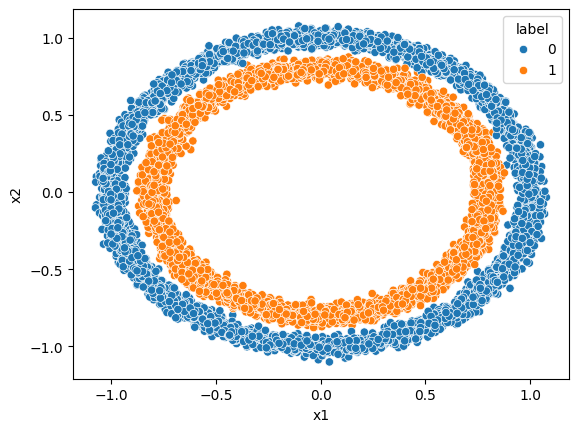

In [38]:
sns.scatterplot(x=df['x1'],y=df['x2'],hue=df['label'])

In [39]:
df['label'].value_counts()

label
0    5000
1    5000
Name: count, dtype: int64

In [40]:
x=torch.from_numpy(x).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

In [41]:
x,y

(tensor([[ 0.8663,  0.4476],
         [ 0.5474,  0.5376],
         [ 0.1219, -0.7960],
         ...,
         [-0.5659,  0.8197],
         [-0.8736, -0.4125],
         [ 0.5371, -0.5646]]),
 tensor([0., 1., 1.,  ..., 0., 0., 1.]))

In [42]:
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=18)

In [45]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [54]:
class Binary_Classifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_layer1=nn.Linear(in_features=2,out_features=5)
        self.linear_layer2=nn.Linear(in_features=5,out_features=1)

    def forward(self,x):
        return self.linear_layer2(self.linear_layer1(x))

In [55]:
torch.manual_seed(18)
model=Binary_Classifier()
model.state_dict()

OrderedDict([('linear_layer1.weight',
              tensor([[-0.0059, -0.0583],
                      [-0.1470,  0.3566],
                      [ 0.5968,  0.1478],
                      [ 0.0723,  0.0623],
                      [-0.4643, -0.4003]])),
             ('linear_layer1.bias',
              tensor([-0.6578,  0.6303,  0.0312, -0.3052,  0.5674])),
             ('linear_layer2.weight',
              tensor([[ 0.1790,  0.2539,  0.0047, -0.2269,  0.1138]])),
             ('linear_layer2.bias', tensor([0.2183]))])

In [58]:
torch.manual_seed(18)
model_replica=nn.Sequential(
    nn.Linear(in_features=2,out_features=5),
    nn.Linear(in_features=5,out_features=1)
)

In [59]:
model_replica.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0059, -0.0583],
                      [-0.1470,  0.3566],
                      [ 0.5968,  0.1478],
                      [ 0.0723,  0.0623],
                      [-0.4643, -0.4003]])),
             ('0.bias', tensor([-0.6578,  0.6303,  0.0312, -0.3052,  0.5674])),
             ('1.weight',
              tensor([[ 0.1790,  0.2539,  0.0047, -0.2269,  0.1138]])),
             ('1.bias', tensor([0.2183]))])

In [61]:
loss_func=nn.BCEWithLogitsLoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.01)

In [71]:
epochs=10000
for _ in range(epochs):
    y_logit=model(x_train).squeeze()
    y_pred=torch.round(torch.sigmoid(y_logit))
    loss=loss_func(y_logit,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [72]:
model.state_dict()

OrderedDict([('linear_layer1.weight',
              tensor([[ 0.0319, -0.0928],
                      [-0.1270,  0.3403],
                      [ 0.6016,  0.1425],
                      [ 0.0465,  0.0850],
                      [-0.4610, -0.4025]])),
             ('linear_layer1.bias',
              tensor([-0.6897,  0.6006,  0.0303, -0.2761,  0.5574])),
             ('linear_layer2.weight',
              tensor([[ 0.2851,  0.1056,  0.0651, -0.1867,  0.0199]])),
             ('linear_layer2.bias', tensor([0.0769]))])

In [73]:
model.eval()
with torch.inference_mode():
    y_test_logit=model(x_test).squeeze()
    y_test_pred=torch.round(torch.sigmoid(y_test_logit))

In [75]:
accuracy_score(y_test,y_test_pred)

0.5065